## Importaciones

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dask.dataframe as dd
import os
from dotenv import load_dotenv
import ee
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import s3fs
import re
import unicodedata
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

## Configuración de acceso y extracción de datos

In [2]:
# ─── CONFIGURACIÓN DE ACCESO ───
load_dotenv()

storage_options = {
    "key": os.getenv("WASABI_ACCESS_KEY"),
    "secret": os.getenv("WASABI_SECRET_KEY"),
    "client_kwargs": {"endpoint_url": "https://s3.us-east-1.wasabisys.com"}
}


In [3]:
RAW_PATH = "s3://data-geo-raw/raw/year=*/month=*/*.csv"
CLEAN_PATH = "s3://data-geovision-clean/GeoVision_Panel/datos_estaciones_limpios.parquet"

print("Leyendo datos raw desde Wasabi...")
# Dask lee todos los CSVs en paralelo
ddf = dd.read_csv(RAW_PATH, storage_options=storage_options, low_memory=False, dtype={'latitud': 'object', 'longitud': 'object'})

Leyendo datos raw desde Wasabi...


## Información del dataset

In [4]:
ddf.head()

,estacion_id,nombre_fgda,nombre_est,msfl_code,med_concentracion_estandar,med_fecha_inicio,med_fecha_final,latitud,longitud,altitud,nombre_unidad,sigla_unidad,duraci_n,codigo_departamento,departamento,codigo_municipio,municipio,tipo_estacion
0,30004,DAGMA,ERA OBRERO,PLiquida,0.25,2020-01-01T00:00:00.000,2020-01-01T01:00:00.000,3.457317,-76.506539,968,Milimetros,mm,60,76,Valle del Cauca,76001,Santiago de Cali,Fija
1,30004,DAGMA,ERA OBRERO,RGlobal,0.00,2020-01-01T00:00:00.000,2020-01-01T01:00:00.000,3.457317,-76.506539,968,Vatios hora por metro cuadrado,Wh/m2,60,76,Valle del Cauca,76001,Santiago de Cali,Fija
2,8288,DAGMA,PANCE,HAire2,92.90,2020-01-01T00:00:00.000,2020-01-01T01:00:00.000,3.304517,-76.531252,978,Porcentaje,%,60,76,Valle del Cauca,76001,Santiago de Cali,Fija
3,30004,DAGMA,ERA OBRERO,VViento,1.30,2020-01-01T00:00:00.000,2020-01-01T01:00:00.000,3.457317,-76.506539,968,Metros por segundo,m/s,60,76,Valle del Cauca,76001,Santiago de Cali,Fija
4,30110,DAGMA,COMPARTIR,PLiquida,0.20,2020-01-01T00:00:00.000,2020-01-01T01:00:00.000,3.42826,-76.466584,952,Milimetros,mm,60,76,Valle del Cauca,76001,Santiago de Cali,Fija


## Limpieza de los datos

### Renombrar y seleccionar columnas

In [5]:
# 1. Renombrar y seleccionar
columnas_utiles = {
    'med_fecha_inicio': 'fecha',
    'nombre_est': 'estacion', 
    'nombre_fgda': 'entidad',
    'msfl_code': 'contaminante',
    'med_concentracion_estandar': 'concentracion',
    'latitud': 'lat',
    'longitud': 'lon'
}
ddf = ddf.rename(columns=columnas_utiles)[list(columnas_utiles.values())]
ddf.head()

,fecha,estacion,entidad,contaminante,concentracion,lat,lon
0,2020-01-01T00:00:00.000,ERA OBRERO,DAGMA,PLiquida,0.25,3.457317,-76.506539
1,2020-01-01T00:00:00.000,ERA OBRERO,DAGMA,RGlobal,0.00,3.457317,-76.506539
2,2020-01-01T00:00:00.000,PANCE,DAGMA,HAire2,92.90,3.304517,-76.531252
3,2020-01-01T00:00:00.000,ERA OBRERO,DAGMA,VViento,1.30,3.457317,-76.506539
4,2020-01-01T00:00:00.000,COMPARTIR,DAGMA,PLiquida,0.20,3.42826,-76.466584


### Convertir a df de pandas

In [6]:
df = ddf.compute()

### Cantidad de datos

In [7]:
print("\nTotal de datos cargados: ", len(df))


Total de datos cargados:  3829785


### Tipos de datos

In [8]:
print("\nTipo de datos:")
print(df.dtypes)


Tipo de datos:
fecha             string
estacion          string
entidad           string
contaminante      string
concentracion    float64
lat               string
lon               string
dtype: object


### Conversión de datos

In [9]:
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')

print(df[['lat', 'lon']].dtypes)

lat    Float64
lon    Float64
dtype: object


### Filtro Geoespacial 

Recortar a las coordenadas que necesitamos

In [10]:
# 3. Filtro Geoespacial (BBox Cali/Yumbo)
df = df[
    (df['lat'] >= 3.20) & (df['lat'] <= 3.75) &
    (df['lon'] >= -76.75) & (df['lon'] <= -76.30)
]

### Filtrar por fecha

In [11]:
# Filtrar periodo 2020-01-01 a 2024-12-31
start = pd.Timestamp('2020-01-01')
end = pd.Timestamp('2024-12-31 23:59:59')

df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df = df[(df['fecha'] >= start) & (df['fecha'] <= end)].reset_index(drop=True)

print("Filas tras filtro:", len(df))
print("Rango fechas:", df['fecha'].min(), "-", df['fecha'].max())

Filas tras filtro: 3139610
Rango fechas: 2020-01-01 00:00:00 - 2024-12-31 23:00:00


In [12]:
df.head()

,fecha,estacion,entidad,contaminante,concentracion,lat,lon
0,2020-01-01,ERA OBRERO,DAGMA,PLiquida,0.25,3.457317,-76.506539
1,2020-01-01,ERA OBRERO,DAGMA,RGlobal,0.00,3.457317,-76.506539
2,2020-01-01,PANCE,DAGMA,HAire2,92.90,3.304517,-76.531252
3,2020-01-01,ERA OBRERO,DAGMA,VViento,1.30,3.457317,-76.506539
4,2020-01-01,COMPARTIR,DAGMA,PLiquida,0.20,3.42826,-76.466584


### Valores únicos de `estacion` y `entidad`

In [13]:
print("Estaciones únicas:")
print(df['estacion'].unique())
print(f"\nTotal de estaciones: {df['estacion'].nunique()}")

print("\n" + "="*50)
print("Entidades únicas:")
print(df['entidad'].unique())
print(f"\nTotal de entidades: {df['entidad'].nunique()}")

Estaciones únicas:
<ArrowStringArray>
[           'ERA OBRERO',                 'PANCE',             'COMPARTIR',
              'LA FLORA', 'UNIVERSIDAD DEL VALLE',             'LA ERMITA',
          'CAÑAVERALEJO',                 'ACOPI',            'BASE AÉREA',
                'URBANO',               'PALMIRA',   'TRANSITORIA-NAVARRO',
          'LAS AMÉRICAS',              'CASCAJAL',            'LA DOLORES',
                 'MOVIL',      'ESTACIÓN JAMUNDÍ',        'ESTACIÓN YUMBO']
Length: 18, dtype: string

Total de estaciones: 18

Entidades únicas:
<ArrowStringArray>
['DAGMA', 'CVC']
Length: 2, dtype: string

Total de entidades: 2


In [14]:
estaciones_objetivo = [
    'ERA OBRERO', 'PANCE', 'COMPARTIR', 'LA FLORA',
    'UNIVERSIDAD DEL VALLE', 'LA ERMITA',
    'CAÑAVERALEJO', 'BASE AÉREA', 'LAS AMÉRICAS', 'ACOPI'
]

df = df[df['estacion'].isin(estaciones_objetivo)].reset_index(drop=True)

print("Estaciones retenidas:", df['estacion'].unique())
print("Filas:", len(df))

Estaciones retenidas: <ArrowStringArray>
[           'ERA OBRERO',                 'PANCE',             'COMPARTIR',
              'LA FLORA', 'UNIVERSIDAD DEL VALLE',             'LA ERMITA',
          'CAÑAVERALEJO',                 'ACOPI',            'BASE AÉREA',
          'LAS AMÉRICAS']
Length: 10, dtype: string
Filas: 1725859


Dejar solo las estaciones que pertenecen a Cali y a la zona de ACOPI

### Selección de contaminantes (SO2, NO2, O3)

In [16]:
df['contaminante'] = df['contaminante'].str.upper().str.strip()
df = df[df['contaminante'].isin(['NO2', 'SO2', 'O3'])]

In [17]:
print("Estaciones retenidas:", df['estacion'].unique())
print("Filas:", len(df))

Estaciones retenidas: <ArrowStringArray>
[            'LA ERMITA',              'LA FLORA',                 'PANCE',
          'CAÑAVERALEJO',             'COMPARTIR',            'ERA OBRERO',
            'BASE AÉREA', 'UNIVERSIDAD DEL VALLE']
Length: 8, dtype: string
Filas: 65484


In [18]:
print(len(df))

65484


###  Revisión de nulos

In [19]:
print("Nulos por columna:")
print(df.isna().sum())

print("\nPorcentaje de valores nulos por columna:")
print((df.isna().mean() * 100).round(2))

Nulos por columna:
fecha            0
estacion         0
entidad          0
contaminante     0
concentracion    0
lat              0
lon              0
dtype: int64

Porcentaje de valores nulos por columna:
fecha            0.0
estacion         0.0
entidad          0.0
contaminante     0.0
concentracion    0.0
lat              0.0
lon              0.0
dtype: float64


### Estaciones que no tienen registro de NO2

In [20]:
no2_stations = df[df['contaminante'].str.upper().str.strip() == 'NO2']['estacion'].drop_duplicates()
all_stations = df['estacion'].drop_duplicates()

estaciones_sin_no2 = all_stations[~all_stations.isin(no2_stations)]
print("Estaciones sin registros de NO2:")
print(estaciones_sin_no2.tolist())

Estaciones sin registros de NO2:
['LA ERMITA', 'LA FLORA', 'PANCE', 'CAÑAVERALEJO', 'COMPARTIR', 'ERA OBRERO', 'BASE AÉREA', 'UNIVERSIDAD DEL VALLE']


Ninguna estación tiene registros de NO2, se tiene un dataset con registros de datos del DAGMA que podrías servir para rellenar los datos de NO2. 

### Pasar los datos a minúsculas

In [21]:
df['estacion'] = df['estacion'].str.lower()
df['entidad'] = df['entidad'].str.lower()

df.head()

,fecha,estacion,entidad,contaminante,concentracion,lat,lon
21,2020-01-01,la ermita,dagma,SO2,2.62,3.455514,-76.530978
26,2020-01-01,la flora,dagma,O3,4.65,3.488218,-76.518058
33,2020-01-01,pance,dagma,O3,17.79,3.304517,-76.531252
37,2020-01-01,cañaveralejo,dagma,SO2,0.05,3.416366,-76.549613
38,2020-01-01,compartir,dagma,O3,10.06,3.42826,-76.466584


### Eliminar la columna de `entidad`

In [22]:
df = df.drop(columns=['entidad'])
df.head()

,fecha,estacion,contaminante,concentracion,lat,lon
21,2020-01-01,la ermita,SO2,2.62,3.455514,-76.530978
26,2020-01-01,la flora,O3,4.65,3.488218,-76.518058
33,2020-01-01,pance,O3,17.79,3.304517,-76.531252
37,2020-01-01,cañaveralejo,SO2,0.05,3.416366,-76.549613
38,2020-01-01,compartir,O3,10.06,3.42826,-76.466584


## Datos de NO2 proporcionados por el profe

El archivo tiene los datos de la medición de NO2 en la estación de Univalle y la Flora, el problema es que de los datos de univalle el 78% son nulos y de la flora todos son nulos. Por lo que estos datos no sirven de mucho. 

### Revisar los datos proporcionados del DAGMA

In [78]:
import pandas as pd
import numpy as np

XLSX_PATH = r"../data/sisaire/SVCASC_FT_50-Datos_Monitores_SVCASC_2020-2025.xlsx"


def load_gas_dagma(path, gas_name):
    """
    Carga de forma dinámica y parametrizada cualquier gas del archivo de SISAIRE,
    retornando un DataFrame limpio en formato largo (long format).
    """
    # 1. Leer el archivo excel respetando la cabecera MultiIndex de 3 niveles
    df = pd.read_excel(path, skiprows=22, header=[0, 1, 2], engine="openpyxl")

    fecha_col = df.columns[0]

    # 2. Buscar columnas correspondientes al gas solicitado (case-insensitive)
    gas_cols = []
    for col in df.columns:
        contaminante = str(col[1]).upper().strip()
        if gas_name.upper() in contaminante:
            gas_cols.append(col)

    if len(gas_cols) == 0:
        print(f"Advertencia: No se encontraron columnas para el gas {gas_name}")
        return pd.DataFrame(columns=["fecha", "estacion", "concentracion", "contaminante"])

    # 3. Extraer columnas del gas y la fecha
    sub = df[[fecha_col] + gas_cols].copy()

    # 4. Renombrar las columnas al nombre de la estación (Nivel 0 del MultiIndex)
    new_cols = ["fecha"]
    for col in gas_cols:
        estacion = str(col[0]).strip()
        new_cols.append(estacion)
    sub.columns = new_cols

    # 5. Convertir la columna fecha a formato datetime
    sub["fecha"] = pd.to_datetime(sub["fecha"], errors="coerce")

    # 6. Transformar a formato largo (Long format) para facilitar la concatenación
    df_long = sub.melt(id_vars="fecha", var_name="estacion", value_name="concentracion")

    # 7. Limpieza de tipos de datos
    df_long["concentracion"] = pd.to_numeric(df_long["concentracion"], errors="coerce")
    df_long["contaminante"] = gas_name.upper()
    
    # Descartar filas con fechas nulas (si las hubiera en las filas de firma del excel)
    df_long = df_long.dropna(subset=["fecha"])

    return df_long.reset_index(drop=True)

In [79]:
print("1. Cargando gases de forma independiente...")
df_no2 = load_gas_dagma(XLSX_PATH, "NO2")
df_so2 = load_gas_dagma(XLSX_PATH, "SO2")
df_o3  = load_gas_dagma(XLSX_PATH, "O3")

print(f"   -> NO2 cargado con {len(df_no2)} filas.")
print(f"   -> SO2 cargado con {len(df_so2)} filas.")
print(f"   -> O3  cargado con {len(df_o3)} filas.")

1. Cargando gases de forma independiente...
   -> NO2 cargado con 39744 filas.
   -> SO2 cargado con 99360 filas.
   -> O3  cargado con 139104 filas.


In [80]:
df_so2.head()

,fecha,estacion,concentracion,contaminante
0,2020-01-01 01:00:00,Base Aerea,NaN,SO2
1,2020-01-01 02:00:00,Base Aerea,NaN,SO2
2,2020-01-01 03:00:00,Base Aerea,NaN,SO2
3,2020-01-01 04:00:00,Base Aerea,NaN,SO2
4,2020-01-01 05:00:00,Base Aerea,NaN,SO2


In [81]:
# Concatenar los tres dataframes en formato largo unificado
print("\n2. Concatenando todos los registros...")
df_final = pd.concat([df_no2, df_so2, df_o3, df], ignore_index=True)
print(f"   -> Filas brutas totales concatenadas: {len(df_final)}")


2. Concatenando todos los registros...
   -> Filas brutas totales concatenadas: 378064


In [82]:
df_final = df_final.map(lambda x: x.lower() if isinstance(x, str) else x)

In [83]:
# REVISIÓN Y DEPURACIÓN DE DUPLICADOS por [fecha, contaminante, estacion]
print("\n3. Revisando registros duplicados por clave [fecha, contaminante, estacion]...")
# Identificar cuántos duplicados hay antes de eliminarlos (keep=False cuenta todas las apariciones)
filas_duplicadas = df_final.duplicated(subset=["fecha", "contaminante", "estacion"], keep=False).sum()

if filas_duplicadas > 0:
    print(f"   -> Se detectaron {filas_duplicadas} filas duplicadas en el cruce de datos.")
    # Eliminar duplicados manteniendo el primer registro que aparezca
    df_final = df_final.drop_duplicates(
        subset=["fecha", "contaminante", "estacion"], 
        keep="first"
    ).reset_index(drop=True)
    print(f"   -> Duplicados eliminados de forma exitosa.")
else:
    print("   -> No se encontraron registros duplicados en el conjunto concatenado.")


3. Revisando registros duplicados por clave [fecha, contaminante, estacion]...
   -> Se detectaron 31654 filas duplicadas en el cruce de datos.
   -> Duplicados eliminados de forma exitosa.


In [84]:
print(len(df_final))

362237


In [85]:
start = pd.Timestamp('2020-01-01')
end = pd.Timestamp('2024-12-31 23:59:59')

df_final['fecha'] = pd.to_datetime(df_final['fecha'], errors='coerce')
df_final = df_final[(df_final['fecha'] >= start) & (df_final['fecha'] <= end)].reset_index(drop=True)

print("Filas tras filtro:", len(df_final))
print("Rango fechas:", df_final['fecha'].min(), "-", df_final['fecha'].max())

Filas tras filtro: 315869
Rango fechas: 2020-01-01 00:00:00 - 2024-12-31 23:00:00


In [86]:
print("Nulos por columna:")
print(df_final.isna().sum())

print("\nPorcentaje de valores nulos por columna:")
print((df_final.isna().mean() * 100).round(2))

Nulos por columna:
fecha                 0
estacion              0
concentracion    103010
contaminante          0
lat              231840
lon              231840
año              231840
mes              231840
hora             231840
dtype: int64

Porcentaje de valores nulos por columna:
fecha             0.00
estacion          0.00
concentracion    32.61
contaminante      0.00
lat              73.40
lon              73.40
año              73.40
mes              73.40
hora             73.40
dtype: float64


### Imputar nulos de lat y lon

In [87]:
def _strip_accents(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def _clean_name(s):
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    s = _strip_accents(s)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)   # quitar puntuación
    s = re.sub(r'\s+', ' ', s).strip()
    return s

mapping = {
    "la flora": "la flora",
    "flora": "la flora",
    "univalle": "universidad del valle",
    "universidad del valle": "universidad del valle",
    "base aerea": "base aerea",
    "base aeria": "base aerea",
    "canaveralejo": "canaveralejo",
    "cahaveralejo": "canaveralejo",  # por si hay typos raros
    "era obrero": "era obrero",
    "era obrero": "era obrero",
    "la ermita": "ermita",
    "ermita": "ermita",
}

def standardize_station(name):
    if pd.isna(name):
        return name
    cleaned = _clean_name(name)
    return mapping.get(cleaned, cleaned)

# Aplicar a todos los DataFrames en globals() que tengan columna 'estacion'
for var_name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and "estacion" in obj.columns:
        obj = obj.copy()
        obj["estacion"] = obj["estacion"].apply(standardize_station)
        globals()[var_name] = obj

# Confirmación mínima (imprime nombres únicos estandarizados por dataframe modificado)
for var_name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and "estacion" in obj.columns:
        print(var_name, "->", sorted(obj["estacion"].dropna().unique()))

_ -> ['base aerea']
__ -> ['la flora']
___ -> ['canaveralejo', 'compartir', 'ermita', 'la flora', 'pance']
_5 -> ['compartir', 'era obrero', 'pance']
df -> ['acopi', 'base aerea', 'canaveralejo', 'compartir', 'era obrero', 'ermita', 'la flora', 'pance', 'universidad del valle']
_12 -> ['compartir', 'era obrero', 'pance']
acopi -> ['acopi']
_21 -> ['canaveralejo', 'compartir', 'ermita', 'la flora', 'pance']
_22 -> ['canaveralejo', 'compartir', 'ermita', 'la flora', 'pance']
df_yumbo -> ['acopi']
_23 -> ['compartir', 'ermita', 'palmira', 'universidad del valle']
_25 -> ['acopi']
df_yumbo2 -> ['acopi']
df2 -> ['base aerea', 'canaveralejo', 'compartir', 'era obrero', 'ermita', 'la flora', 'pance', 'universidad del valle']
df_yumbo_sel -> ['acopi']
df_combined -> ['acopi', 'base aerea', 'canaveralejo', 'compartir', 'era obrero', 'ermita', 'la flora', 'pance', 'universidad del valle']
_36 -> ['canaveralejo', 'compartir', 'ermita', 'la flora', 'pance']
df_top -> ['acopi', 'base aerea', 'canav

In [88]:
# =====================================================================
# PROCESO DE IMPUTACIÓN VECTORIAL
# =====================================================================

# 1. Asegurar la existencia de las columnas 'lat' y 'lon' en el DataFrame
if "lat" not in df_final.columns:
    df_final["lat"] = np.nan
if "lon" not in df_final.columns:
    df_final["lon"] = np.nan

# 2. Contar nulos iniciales para el reporte
nulos_lat_inicial = df_final["lat"].isna().sum()
nulos_lon_inicial = df_final["lon"].isna().sum()
print("=== INICIANDO IMPUTACIÓN DE COORDENADAS ===")
print(f"   -> Nulos iniciales detectados: Latitud: {nulos_lat_inicial} | Longitud: {nulos_lon_inicial}")

# 3. Extraer el mapeo estación -> coordenada de las filas que SÍ tienen datos válidos
df_valid_coords = df_final.dropna(subset=["lat", "lon"])[["estacion", "lat", "lon"]].drop_duplicates("estacion")

map_lat_dataset = df_valid_coords.set_index("estacion")["lat"].to_dict()
map_lon_dataset = df_valid_coords.set_index("estacion")["lon"].to_dict()

print(f"   -> Estaciones georreferenciadas encontradas: {list(map_lat_dataset.keys())}")


# 5. Rellenar los valores nulos mediante mapeo vectorial de alta velocidad (mmap)
df_final["lat"] = df_final["lat"].fillna(df_final["estacion"].map(map_lat_dataset))
df_final["lon"] = df_final["lon"].fillna(df_final["estacion"].map(map_lon_dataset))

# =====================================================================
# REPORTE DE INTEGRIDAD FINAL
# =====================================================================
nulos_lat_final = df_final["lat"].isna().sum()
nulos_lon_final = df_final["lon"].isna().sum()

print("\n" + "="*60)
print("REPORTE DE GEORREFERENCIACIÓN (SITUACIÓN 3)")
print("="*60)
print(f"1. Nulos finales de Latitud    : {nulos_lat_final}")
print(f"2. Nulos finales de Longitud   : {nulos_lon_final}")

if nulos_lat_final > 0:
    estaciones_huerfanas = df_final[df_final["lat"].isna()]["estacion"].unique()
    print(f"Advertencia: Las siguientes estaciones no tienen coordenadas asignadas: {estaciones_huerfanas}")
else:
    print("INTEGRIDAD TOTAL: El 100% de las filas de las estaciones tienen sus coordenadas (lat, lon) asignadas.")
print("="*60)

=== INICIANDO IMPUTACIÓN DE COORDENADAS ===
   -> Nulos iniciales detectados: Latitud: 231840 | Longitud: 231840
   -> Estaciones georreferenciadas encontradas: ['acopi', 'la flora', 'pance', 'compartir', 'era obrero', 'base aerea', 'universidad del valle', 'ermita', 'canaveralejo']

REPORTE DE GEORREFERENCIACIÓN (SITUACIÓN 3)
1. Nulos finales de Latitud    : 33120
2. Nulos finales de Longitud   : 33120
Advertencia: Las siguientes estaciones no tienen coordenadas asignadas: <ArrowStringArray>
['transitoria navarro']
Length: 1, dtype: str


In [89]:
# Eliminar filas con la estación "transitoria navarro" de todos los DataFrames con columna 'estacion'
target = "transitoria navarro"

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and "estacion" in obj.columns:
        orig = len(obj)
        mask = obj["estacion"].astype(str).str.lower().str.strip() != target
        if mask.all():
            continue
        globals()[name] = obj.loc[mask].reset_index(drop=True)
        print(f"{name}: eliminadas {orig - len(globals()[name])} filas")

# Quitar de mapas de coordenadas si existen
for dname in ("map_lat_dataset", "map_lon_dataset"):
    if dname in globals() and isinstance(globals()[dname], dict):
        globals()[dname].pop(target, None)

df_so2: eliminadas 19872 filas
df_o3: eliminadas 19872 filas
df_final: eliminadas 33120 filas


In [90]:
print(df_final.isna().sum())

fecha                 0
estacion              0
concentracion     74810
contaminante          0
lat                   0
lon                   0
año              198720
mes              198720
hora             198720
dtype: int64


### Imputar nulos de año y mes

In [91]:
# Añadir columnas 'año' y 'mes' a df (asumiendo df['fecha'] ya es datetime)
df_final['fecha'] = pd.to_datetime(df_final['fecha'], errors='coerce')
df_final['año'] = df_final['fecha'].dt.year.astype('Int64')
df_final['mes'] = df_final['fecha'].dt.month.astype('Int64')
df_final.head()

,fecha,estacion,concentracion,contaminante,lat,lon,año,mes,hora
0,2020-01-01 01:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,NaN
1,2020-01-01 02:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,NaN
2,2020-01-01 03:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,NaN
3,2020-01-01 04:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,NaN
4,2020-01-01 05:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,NaN


In [92]:
df_final['hora'] = pd.to_datetime(df_final['fecha']).dt.hour
df_final.head()

,fecha,estacion,concentracion,contaminante,lat,lon,año,mes,hora
0,2020-01-01 01:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,1
1,2020-01-01 02:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,2
2,2020-01-01 03:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,3
3,2020-01-01 04:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,4
4,2020-01-01 05:00:00,la flora,NaN,no2,3.488218,-76.518058,2020,1,5


### Revisar nulos por estacion y resolver que hacer con eso

In [93]:
summary = (
    df_final.groupby(['estacion', 'contaminante'])['concentracion']
    .agg(total='size',
         n_null=lambda x: x.isna().sum(),
         pct_null=lambda x: x.isna().mean() * 100)
    .reset_index()
    .sort_values(['pct_null', 'total'], ascending=[False, False])
)

# Mostrar resumen y pivotes útiles
print("Resumen (ordenado por % nulos):")
display(summary)

print("\n% nulos por estación x contaminante:")
display(summary.pivot(index='estacion', columns='contaminante', values='pct_null').fillna(0).round(2))

print("\nConteo de nulos por estación x contaminante:")
display(summary.pivot(index='estacion', columns='contaminante', values='n_null').fillna(0).astype(int))

Resumen (ordenado por % nulos):


,estacion,contaminante,total,n_null,pct_null
9,la flora,no2,16560,16560,100.000000
13,universidad del valle,no2,16560,6388,38.574879
4,base aerea,so2,21108,7991,37.857684
11,la flora,so2,20725,7198,34.731001
10,la flora,o3,22462,7544,33.585611
7,era obrero,o3,23499,6488,27.609686
3,base aerea,o3,21101,5487,26.003507
5,canaveralejo,so2,19756,4452,22.534926
14,universidad del valle,o3,22910,3910,17.066783
6,compartir,o3,21155,3346,15.816592



% nulos por estación x contaminante:


contaminante,no2,o3,so2
estacion,,,
acopi,0.00,0.00,0.00
base aerea,0.00,26.00,37.86
canaveralejo,0.00,0.00,22.53
compartir,0.00,15.82,0.00
era obrero,0.00,27.61,0.00
ermita,0.00,0.00,11.50
la flora,100.00,33.59,34.73
pance,0.00,14.21,0.00
universidad del valle,38.57,17.07,0.00



Conteo de nulos por estación x contaminante:


contaminante,no2,o3,so2
estacion,,,
acopi,0,0,0
base aerea,0,5487,7991
canaveralejo,0,0,4452
compartir,0,3346,0
era obrero,0,6488,0
ermita,0,0,2538
la flora,16560,7544,7198
pance,0,2908,0
universidad del valle,6388,3910,0


#### Imputación por k-nn porque no eran muchos valores faltantes

In [94]:
# 1) Eliminar filas de NO2 en la estación "la flora" (case-insensitive)
mask_drop = df['estacion'].astype(str).str.lower().eq('la flora') & df['contaminante'].astype(str).str.upper().eq('NO2')
df = df.loc[~mask_drop].reset_index(drop=True)
print("Filas tras eliminar NO2 en la flora:", len(df))

# 2) Preparar columnas temporales si faltan
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['año']  = df['fecha'].dt.year
df['mes']  = df['fecha'].dt.month
df['hora'] = df['fecha'].dt.hour

# 3) Imputación por interpolación lineal por estación y contaminante (en el tiempo)
df = df.sort_values(['estacion','contaminante','fecha']).reset_index(drop=True)

def _interp_group(g):
    # Si no hay ningún valor observado para concentración, dejar sin cambios
    if g['concentracion'].notna().sum() == 0:
        return g
    g = g.sort_values('fecha').set_index('fecha')
    # Interpolación por tiempo. 'limit_direction="both"' rellena NaNs entre y en los extremos cuando es posible.
    try:
        g['concentracion'] = g['concentracion'].interpolate(method='time', limit_direction='both')
    except Exception:
        # Fallback a interpolación lineal por índice si 'time' falla (p.ej. fechas duplicadas o no-datetime index)
        g['concentracion'] = g['concentracion'].interpolate(method='linear', limit_direction='both')
    return g.reset_index()

df = df.groupby(['estacion','contaminante'], group_keys=False).apply(_interp_group).reset_index(drop=True)

# Ver cuántos nulos quedan
nulos_restantes = df['concentracion'].isna().sum()
print("Nulos restantes en 'concentracion':", nulos_restantes)

Filas tras eliminar NO2 en la flora: 99856
Nulos restantes en 'concentracion': 0


### Dataset final

In [95]:
df = df_final

## Datos de Yumbo

In [23]:
df_yumbo = pd.read_csv("../data/sisaire/data_estaciones.csv")
df_yumbo.head()

,fecha,estacion,autoridad,contaminante,concentracion,lat,lon,año,mes
0,2020-09-04 10:00:00,TRANSITORIA-NAVARRO,DAGMA,O3,5.96,3.417183,-76.494960,2020,9
1,2020-07-22 11:00:00,LA ERMITA,DAGMA,SO2,0.00,3.455514,-76.530978,2020,7
2,2020-09-09 03:00:00,PALMIRA,CVC,O3,0.60,3.537500,-76.300833,2020,9
3,2020-10-25 23:00:00,COMPARTIR,DAGMA,O3,13.65,3.428260,-76.466584,2020,10
4,2020-12-29 23:00:00,UNIVERSIDAD DEL VALLE,DAGMA,O3,6.65,3.377911,-76.533811,2020,12


In [24]:
df_yumbo = df_yumbo[df_yumbo["estacion"] == "ESTACIÓN YUMBO"].copy()

df_yumbo["estacion"] = "ACOPI"
print(df_yumbo["estacion"].unique())

<ArrowStringArray>
['ACOPI']
Length: 1, dtype: str


In [25]:
df_yumbo.head()

,fecha,estacion,autoridad,contaminante,concentracion,lat,lon,año,mes
11,2020-12-27 16:00:00,ACOPI,CVC,NO2,2.80,3.579075,-76.489558,2020,12
18,2020-11-30 07:00:00,ACOPI,CVC,O3,11.30,3.579075,-76.489558,2020,11
19,2020-12-12 23:00:00,ACOPI,CVC,O3,12.20,3.579075,-76.489558,2020,12
39,2020-11-09 01:00:00,ACOPI,CVC,NO2,0.02,3.579075,-76.489558,2020,11
54,2020-11-03 22:00:00,ACOPI,CVC,O3,23.00,3.579075,-76.489558,2020,11


In [26]:
df_yumbo['fecha'] = pd.to_datetime(df_yumbo['fecha'])
df_yumbo.dtypes

fecha            datetime64[us]
estacion                    str
autoridad                   str
contaminante                str
concentracion           float64
lat                     float64
lon                     float64
año                       int64
mes                       int64
dtype: object

In [28]:
# Normalizar y concatenar df y df_yumbo
df_yumbo2 = df_yumbo.copy()

# Renombrar autoridad -> entidad si existe
if 'autoridad' in df_yumbo2.columns:
    df_yumbo2 = df_yumbo2.rename(columns={'autoridad': 'entidad'})

# Asegurar columnas esperadas
expected = ['fecha', 'estacion', 'contaminante', 'concentracion', 'lat', 'lon']
for c in expected:
    if c not in df_yumbo2.columns:
        df_yumbo2[c] = pd.NA

# Estandarizar formatos
df2 = df.copy()
df2['estacion'] = df2['estacion'].astype(str).str.strip().str.upper()
df_yumbo2['estacion'] = df_yumbo2['estacion'].astype(str).str.strip().str.upper()

df2['contaminante'] = df2['contaminante'].astype(str).str.strip().str.upper()
df_yumbo2['contaminante'] = df_yumbo2['contaminante'].astype(str).str.strip().str.upper()

df2['fecha'] = pd.to_datetime(df2['fecha'], errors='coerce')
df_yumbo2['fecha'] = pd.to_datetime(df_yumbo2['fecha'], errors='coerce')

df2['lat'] = pd.to_numeric(df2['lat'], errors='coerce')
df2['lon'] = pd.to_numeric(df2['lon'], errors='coerce')
df_yumbo2['lat'] = pd.to_numeric(df_yumbo2['lat'], errors='coerce')
df_yumbo2['lon'] = pd.to_numeric(df_yumbo2['lon'], errors='coerce')

# Seleccionar columnas y concatenar
df_yumbo_sel = df_yumbo2[expected]
df_combined = pd.concat([df2[expected], df_yumbo_sel], ignore_index=True)

# Eliminar duplicados exactos y reset index
df_combined = df_combined.drop_duplicates(subset=['fecha', 'estacion', 'contaminante', 'lat', 'lon']).reset_index(drop=True)

# Reemplazar/guardar resultado
df = df_combined
print("Filas tras unión:", len(df))

Filas tras unión: 99856


In [29]:
df['contaminante'] = df['contaminante'].str.upper().str.strip()
df = df[df['contaminante'].isin(['NO2', 'SO2', 'O3'])]
print(len(df))

99856


In [30]:
print(df.isna().sum())

fecha            0
estacion         0
contaminante     0
concentracion    0
lat              0
lon              0
dtype: int64


In [31]:
print("Estaciones únicas:")
print(df['estacion'].unique())
print(f"\nTotal de estaciones: {df['estacion'].nunique()}")

Estaciones únicas:
<ArrowStringArray>
[            'LA ERMITA',              'LA FLORA',                 'PANCE',
          'CAÑAVERALEJO',             'COMPARTIR',            'ERA OBRERO',
            'BASE AÉREA', 'UNIVERSIDAD DEL VALLE',                 'ACOPI']
Length: 9, dtype: str

Total de estaciones: 9


In [32]:
NEW_LAT = 3.49625
NEW_LON = -76.506972

targets = ['df']

for name in targets:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame) and 'estacion' in obj.columns:
            mask = obj['estacion'].astype(str).str.upper() == 'ACOPI'
            if mask.any():
                obj.loc[mask, 'lat'] = NEW_LAT
                obj.loc[mask, 'lon'] = NEW_LON
                globals()[name] = obj  # re-asignar por si el DF está referenciado

# Confirmación breve
for name in targets:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame) and 'estacion' in obj.columns:
            n = obj[obj['estacion'].astype(str).str.upper() == 'ACOPI'].shape[0]
            if n:
                print(f"{name}: {n} filas con coordenadas actualizadas -> lat={NEW_LAT}, lon={NEW_LON}")

df: 34372 filas con coordenadas actualizadas -> lat=3.49625, lon=-76.506972


## Revisar duplicados

In [105]:
# Revisión rápida de duplicados en `df`

print("Filas totales:", len(df))

# 1) Duplicados exactos (todas las columnas)
exact_dup_mask = df.duplicated(keep=False)
print("Duplicados exactos (todas las columnas):", exact_dup_mask.sum())
if exact_dup_mask.sum() > 0:
    display(df[exact_dup_mask].sort_values(['fecha','estacion','contaminante']).head(50))

# 2) Duplicados por clave lógica [fecha, estacion, contaminante]
keys = ['fecha', 'estacion', 'contaminante']
dup_groups = (
    df.groupby(keys)
      .size()
      .reset_index(name='count')
      .query('count > 1')
      .sort_values('count', ascending=False)
)
print(f"Grupos duplicados por {keys}:", len(dup_groups))
display(dup_groups.head(20))

# 3) Mostrar registros del grupo más duplicado (si existe)
if not dup_groups.empty:
    top = dup_groups.iloc[0][keys].to_dict()
    print("\nEjemplo - registros del grupo más duplicado:", top)
    display(df[
        (df['fecha'] == top['fecha']) &
        (df['estacion'] == top['estacion']) &
        (df['contaminante'] == top['contaminante'])
    ])

Filas totales: 282749
Duplicados exactos (todas las columnas): 0
Grupos duplicados por ['fecha', 'estacion', 'contaminante']: 8817


,fecha,estacion,contaminante,count
11,2020-01-01 01:00:00,era obrero,o3,2
14,2020-01-01 01:00:00,la flora,o3,2
15,2020-01-01 01:00:00,la flora,so2,2
23,2020-01-01 02:00:00,era obrero,o3,2
26,2020-01-01 02:00:00,la flora,o3,2
27,2020-01-01 02:00:00,la flora,so2,2
35,2020-01-01 03:00:00,era obrero,o3,2
38,2020-01-01 03:00:00,la flora,o3,2
39,2020-01-01 03:00:00,la flora,so2,2
47,2020-01-01 04:00:00,era obrero,o3,2



Ejemplo - registros del grupo más duplicado: {'fecha': Timestamp('2020-01-01 01:00:00'), 'estacion': 'era obrero', 'contaminante': 'o3'}


,fecha,estacion,concentracion,lat,lon,hora,contaminante,año,mes
552,2020-01-01 01:00:00,era obrero,NaN,3.457317,-76.506539,1,o3,2020,1
1661,2020-01-01 01:00:00,era obrero,4.47,3.457317,-76.506539,1,o3,2020,1


In [106]:
# Mantener solo, por cada (fecha, estacion, contaminante), la fila que tenga valor en 'concentracion' (si existe).
keys = ['fecha', 'estacion', 'contaminante']

before = len(df)
# Marcar filas con concentración válida
df['_has_conc'] = df['concentracion'].notna().astype(int)

# Ordenar para que las filas con concentración aparezcan primero dentro de cada grupo y luego eliminar duplicados
df = (
    df.sort_values(keys + ['_has_conc'], ascending=[True, True, True, False])
      .drop_duplicates(subset=keys, keep='first')
      .reset_index(drop=True)
)

# Limpieza
df = df.drop(columns=['_has_conc'])

after = len(df)
print(f"Filas antes: {before} -> Filas después: {after} (eliminadas {before-after})")

Filas antes: 282749 -> Filas después: 273932 (eliminadas 8817)


In [123]:
# Convertir tipos de columnas solicitadas
df['contaminante'] = df['contaminante'].astype('string')
df['año'] = pd.to_numeric(df['año'], errors='coerce').astype('Int64')
df['mes'] = pd.to_numeric(df['mes'], errors='coerce').astype('Int64')

# Confirmar cambios
print(df[['contaminante', 'año', 'mes']].dtypes)

contaminante    string
año              Int64
mes              Int64
dtype: object


In [111]:
df.dtypes

fecha            datetime64[us]
estacion                 string
concentracion           float64
lat                     float64
lon                     float64
hora                      int32
contaminante             string
año                       Int64
mes                       Int64
dtype: object

In [124]:
df = df.reset_index(drop=True)

## Subir los datos limpios a wasabi como `.parquet`

In [37]:
# Añadir columnas 'año' y 'mes' a df (asumiendo df['fecha'] ya es datetime)
df['año'] = df['fecha'].dt.year.astype('Int64')
df['mes'] = df['fecha'].dt.month.astype('Int64')

In [125]:
storage_options = {
    "key": os.getenv("WASABI_ACCESS_KEY"),
    "secret": os.getenv("WASABI_SECRET_KEY"),
    "client_kwargs": {"endpoint_url": "https://s3.us-east-1.wasabisys.com"}
}

path_wasabi = "s3://data-geovision-clean/GeoVision_Panel/dataset_estaciones"

print("Conectando a Wasabi y borrando datos previos si existen...")
fs = s3fs.S3FileSystem(key=os.getenv("WASABI_ACCESS_KEY"), secret=os.getenv("WASABI_SECRET_KEY"), client_kwargs={"endpoint_url": "https://s3.us-east-1.wasabisys.com"})

try:
    if fs.exists(path_wasabi):
        print(f"Borrando contenido en {path_wasabi}...")
        fs.rm(path_wasabi, recursive=True)
        print("Borrado completado")
    else:
        print("No se encontró contenido previo. Continuando...")
except Exception as e:
    print("Advertencia: no se pudo borrar el contenido previo:", e)

print("Guardando dataset particionado...")
df.to_parquet(
    path_wasabi,
    engine='pyarrow',
    compression='snappy',
    index=False,
    partition_cols=['contaminante', 'año', 'mes'], 
    storage_options=storage_options
)

Conectando a Wasabi y borrando datos previos si existen...
Borrando contenido en s3://data-geovision-clean/GeoVision_Panel/dataset_estaciones...
Borrado completado
Guardando dataset particionado...


## EDA (Datos limpios)

### Traer datos

In [126]:
PATH_CLEAN = f"s3://data-geovision-clean/GeoVision_Panel/dataset_estaciones"
ddf = dd.read_parquet(PATH_CLEAN, storage_options=storage_options)

# Convertir una muestra o el total a Pandas para el EDA (si el dataset limpio cabe en RAM)
print("Computando datos para el EDA...")
df_eda = ddf.compute() 
df_eda['fecha'] = pd.to_datetime(df_eda['fecha'])

Computando datos para el EDA...


### Distribución temporal de adquicisiones

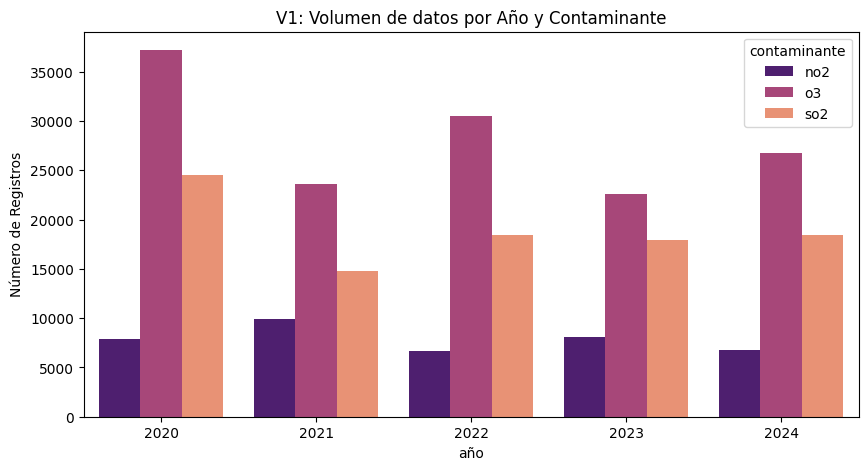

In [127]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='año', hue='contaminante', palette='magma')
plt.title("V1: Volumen de datos por Año y Contaminante")
plt.ylabel("Número de Registros")
plt.show()

### Mapa de cobertura espacial efectiva

In [128]:
fig = px.scatter_mapbox(df.drop_duplicates('estacion'), 
                        lat="lat", lon="lon", 
                        text="estacion",
                        color_discrete_sequence=["red"],
                        zoom=11, height=500)
fig.update_layout(mapbox_style="open-street-map", title="V2: Mapa de Estaciones (Red de Monitoreo)")
fig.show()

C:\Users\natam\AppData\Local\Temp\ipykernel_18924\628022345.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(df.drop_duplicates('estacion'),


### Análisis de disponibilidad de datos

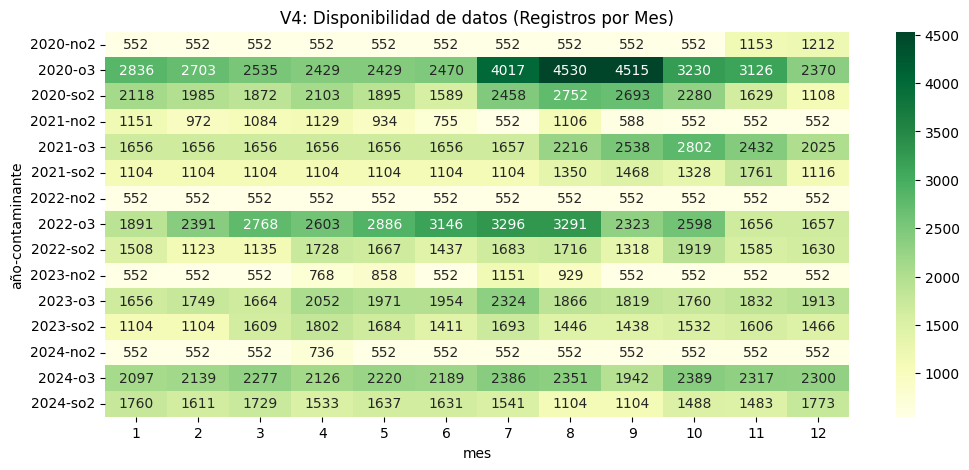

In [129]:
# Contar registros por mes y año
dispo = df.groupby(['año', 'mes', 'contaminante']).size().unstack(level=1).fillna(0)
plt.figure(figsize=(12, 5))
sns.heatmap(dispo, annot=True, fmt=".0f", cmap="YlGn")
plt.title("V4: Disponibilidad de datos (Registros por Mes)")
plt.show()

### Serie temporal media

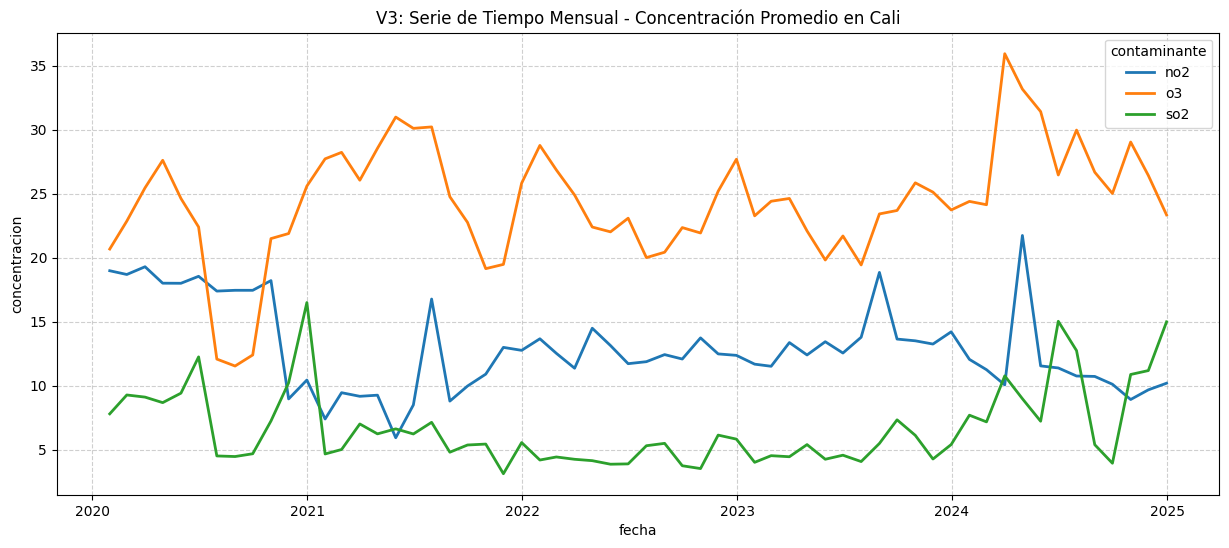

In [130]:
# Agrupar por mes y contaminante
df_ts = df.groupby([pd.Grouper(key='fecha', freq='ME'), 'contaminante'])['concentracion'].mean().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_ts, x='fecha', y='concentracion', hue='contaminante', linewidth=2)
plt.title("V3: Serie de Tiempo Mensual - Concentración Promedio en Cali")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

###  Variabilidad por estación

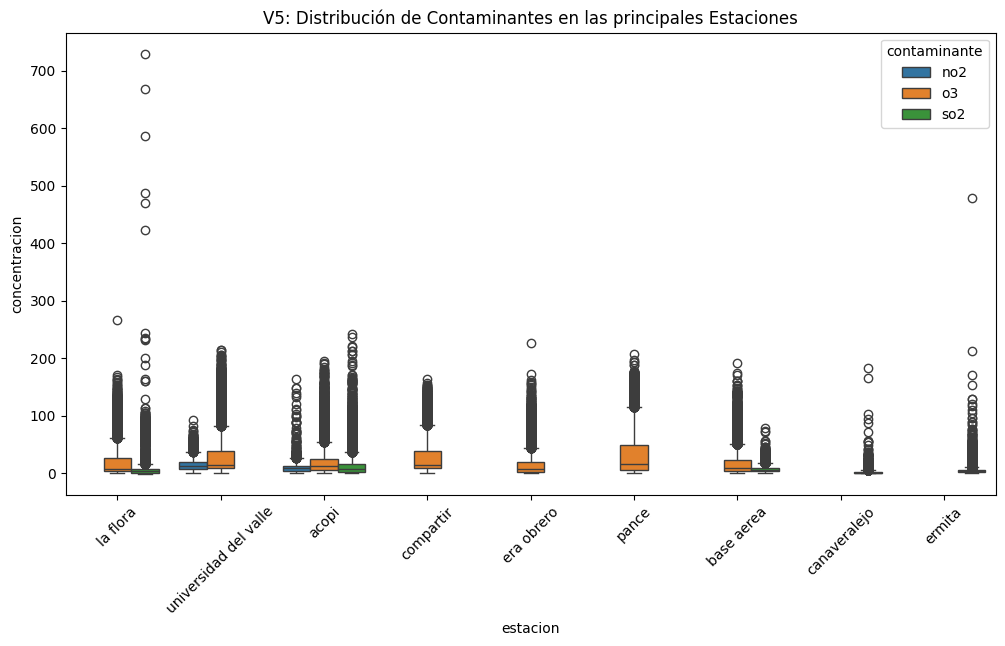

In [131]:
top_estaciones = df['estacion'].value_counts().nlargest(10).index
df_top = df[df['estacion'].isin(top_estaciones)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='estacion', y='concentracion', hue='contaminante')
plt.xticks(rotation=45)
plt.title("V5: Distribución de Contaminantes en las principales Estaciones")
plt.show()

### Ciclo diario de contaminación

C:\Users\natam\AppData\Local\Temp\ipykernel_18924\3891719109.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='hora', y='concentracion', hue='contaminante', ci=None)


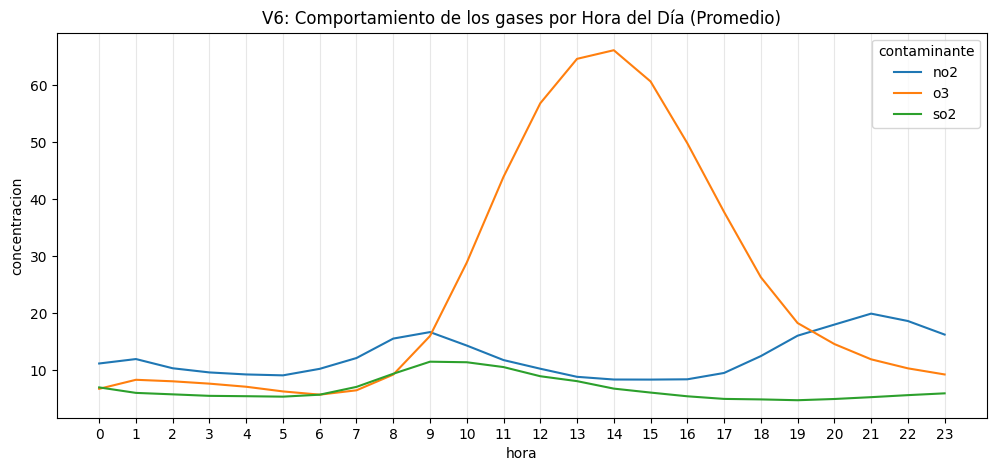

In [132]:
df['hora'] = pd.to_datetime(df['fecha']).dt.hour

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hora', y='concentracion', hue='contaminante', ci=None)
plt.title("V6: Comportamiento de los gases por Hora del Día (Promedio)")
plt.xticks(range(0,24))
plt.grid(axis='x', alpha=0.3)
plt.show()

### Estacionalidad

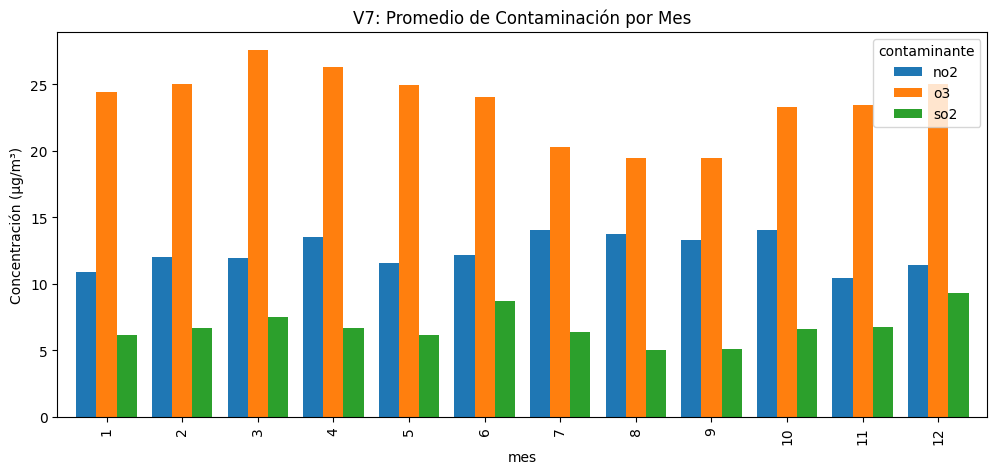

In [133]:
df_month = df.groupby(['mes', 'contaminante'])['concentracion'].mean().unstack()
df_month.plot(kind='bar', figsize=(12, 5), width=0.8)
plt.title("V7: Promedio de Contaminación por Mes")
plt.ylabel("Concentración (µg/m³)")
plt.show()

## Pasar los datos a diarios

In [135]:
# Asegurarse de que 'fecha' es datetime
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

# Agrupar por día y calcular la media de concentración (mantener lat/lon con 'first' y contar registros)
df_diario = (
	df.groupby([pd.Grouper(key='fecha', freq='D'), 'estacion', 'contaminante'])
	  .agg(
		  concentracion=('concentracion', 'mean'),
		  lat=('lat', 'first'),
		  lon=('lon', 'first'),
		  registros=('concentracion', 'size')
	  )
	  .reset_index()
)

# Añadir columnas de año/mes/día
df_diario['año'] = df_diario['fecha'].dt.year.astype('Int64')
df_diario['mes'] = df_diario['fecha'].dt.month.astype('Int64')
df_diario['dia'] = df_diario['fecha'].dt.day.astype('Int64')

df_diario.head()

,fecha,estacion,contaminante,concentracion,lat,lon,registros,año,mes,dia
0,2020-01-01,base aerea,o3,32.609015,3.457128,-76.502303,23,2020,1,1
1,2020-01-01,base aerea,so2,NaN,3.457128,-76.502303,23,2020,1,1
2,2020-01-01,canaveralejo,so2,0.050000,3.416366,-76.549613,24,2020,1,1
3,2020-01-01,compartir,o3,31.808435,3.428260,-76.466584,24,2020,1,1
4,2020-01-01,era obrero,o3,8.463750,3.457317,-76.506539,24,2020,1,1


In [136]:
print(df_diario.isna().sum())

fecha               0
estacion            0
contaminante        0
concentracion    2293
lat                 0
lon                 0
registros           0
año                 0
mes                 0
dia                 0
dtype: int64


In [138]:
# 1) Eliminar filas de NO2 en la estación "la flora" (case-insensitive)
mask_drop = df_diario['estacion'].astype(str).str.lower().eq('la flora') & df_diario['contaminante'].astype(str).str.upper().eq('NO2')
df_diario = df_diario.loc[~mask_drop].reset_index(drop=True)
print("Filas tras eliminar NO2 en la flora:", len(df_diario))

Filas tras eliminar NO2 en la flora: 12189


In [139]:
# Contar nulos por contaminante en cada estación
res = (
    df_diario.groupby(['estacion', 'contaminante'])['concentracion']
      .agg(n_null=lambda x: x.isna().sum(), total='size')
      .reset_index()
      .sort_values(['estacion', 'contaminante'])
)

print(res)

# Pivot para ver estaciones x contaminante (nulos)
pivot = res.pivot(index='estacion', columns='contaminante', values='n_null').fillna(0).astype(int)
print("\nPivot (nulos por contaminante):")
print(pivot)

                 estacion contaminante  n_null  total
0                   acopi          no2       0    331
1                   acopi           o3       0    859
2                   acopi          so2       0    629
3              base aerea           o3     147   1028
4              base aerea          so2     226    978
5            canaveralejo          so2     116    943
6               compartir           o3      65    991
7              era obrero           o3     150    988
8                  ermita          so2      63    994
9                la flora           o3     199    927
10               la flora          so2     222    856
11                  pance           o3      82    979
12  universidad del valle          no2     203    720
13  universidad del valle           o3     100    966

Pivot (nulos por contaminante):
contaminante           no2   o3  so2
estacion                            
acopi                    0    0    0
base aerea               0  147  226
canaveral

#### Imputar por k-nn

In [142]:
# Copia del dataframe
df_knn = df_diario.copy()

# Lista de contaminantes únicos
contaminantes = df_knn['contaminante'].dropna().unique()

# Procesar cada contaminante por separado
for cont in contaminantes:

    # Filtrar solo ese contaminante
    mask = df_knn['contaminante'] == cont

    # Columnas para imputar
    cols = ['año', 'mes', 'concentracion']

    # Subconjunto
    sub_df = df_knn.loc[mask, cols].copy()

    # Convertir a numérico
    sub_df = sub_df.apply(pd.to_numeric, errors='coerce').astype(float)

    # Escalar
    scaler = StandardScaler()
    sub_scaled = scaler.fit_transform(sub_df)

    # Imputación KNN
    imputer = KNNImputer(n_neighbors=5)
    sub_imputed_scaled = imputer.fit_transform(sub_scaled)

    # Regresar a escala original
    sub_imputed = scaler.inverse_transform(sub_imputed_scaled)

    # Reemplazar la columna imputada
    conc_idx = cols.index('concentracion')

    df_knn.loc[mask, 'concentracion'] = sub_imputed[:, conc_idx]

    print(f"{cont} -> nulos restantes:",
          df_knn.loc[mask, 'concentracion'].isna().sum())

# Sobrescribir dataframe original si deseas
df_diario = df_knn

o3 -> nulos restantes: 0
so2 -> nulos restantes: 0
no2 -> nulos restantes: 0


In [143]:
print(df_diario.isna().sum())

fecha            0
estacion         0
contaminante     0
concentracion    0
lat              0
lon              0
registros        0
año              0
mes              0
dia              0
dtype: int64


## Subir los datos otra vez

In [144]:
storage_options = {
    "key": os.getenv("WASABI_ACCESS_KEY"),
    "secret": os.getenv("WASABI_SECRET_KEY"),
    "client_kwargs": {"endpoint_url": "https://s3.us-east-1.wasabisys.com"}
}

path_wasabi = "s3://data-geovision-clean/GeoVision_Panel/dataset_estaciones"

print("Conectando a Wasabi y borrando datos previos si existen...")
fs = s3fs.S3FileSystem(key=os.getenv("WASABI_ACCESS_KEY"), secret=os.getenv("WASABI_SECRET_KEY"), client_kwargs={"endpoint_url": "https://s3.us-east-1.wasabisys.com"})

try:
    if fs.exists(path_wasabi):
        print(f"Borrando contenido en {path_wasabi}...")
        fs.rm(path_wasabi, recursive=True)
        print("Borrado completado")
    else:
        print("No se encontró contenido previo. Continuando...")
except Exception as e:
    print("Advertencia: no se pudo borrar el contenido previo:", e)

print("Guardando dataset particionado...")
df.to_parquet(
    path_wasabi,
    engine='pyarrow',
    compression='snappy',
    index=False,
    partition_cols=['contaminante', 'año', 'mes'], 
    storage_options=storage_options
)

Conectando a Wasabi y borrando datos previos si existen...
Borrando contenido en s3://data-geovision-clean/GeoVision_Panel/dataset_estaciones...
Borrado completado
Guardando dataset particionado...
